# 泛型编程

Julia的函数能够针对不同的自变量类型通过即时编译产生高效代码， 不需要声明自变量类型。

函数可以声明自变量类型和返回值类型， 这可以限定能使用的自变量类型， 避免错误的输入， 使得程序意图更明显； 同一个函数可以有不同类型的自变量， 这其实是多个函数共用同一个函数名， 称这些函数为该函数名的“方法”（methods)。 这种做法称为“多重派发”（multiple dispatch）， 还可以类似于C++模板， 将函数自变量类型参数化， 这样同一代码可以适用于多个自变量类型。

In [49]:
function freq(x)
    y = Dict()
    for xi in x
        y[xi] = get(y, xi, 0) + 1
    end
    return y
end

freq (generic function with 1 method)

In [50]:
sum(1:5)


15

In [51]:
Int32 <: Number

true

In [55]:
age = 35; sex = 'F'

'F': ASCII/Unicode U+0046 (category Lu: Letter, uppercase)

In [58]:
println(age < 18)
println(sex =='M')

false
false


In [59]:
for i = 1:9
    for j = 1:i
        print(j, "×", i, "=", i * j, " ")
    end
    println()
end

1×1=1 
1×2=2 2×2=4 
1×3=3 2×3=6 3×3=9 
1×4=4 2×4=8 3×4=12 4×4=16 
1×5=5 2×5=10 3×5=15 4×5=20 5×5=25 
1×6=6 2×6=12 3×6=18 4×6=24 5×6=30 6×6=36 
1×7=7 2×7=14 3×7=21 4×7=28 5×7=35 6×7=42 7×7=49 
1×8=8 2×8=16 3×8=24 4×8=32 5×8=40 6×8=48 7×8=56 8×8=64 
1×9=9 2×9=18 3×9=27 4×9=36 5×9=45 6×9=54 7×9=63 8×9=72 9×9=81 


求解平方根公式，相当于求根 $f(x)=u^2-x=0$

In [62]:
function mysqrt(x,eps=1E-6)
    u2 = 1.0
    u1 = 0.0
    while abs(u2-u1)>=eps
        u1 = u2
        u2 = 0.5*(u2+x/u2)
    end
    return u2
end
mysqrt(2)

1.414213562373095

In [63]:
for i = 1:5
    println(i)
    if i == 3
        continue
    end
    y = i * i
    println(y)
end

1
1
2
4
3
4
16
5
25


In [64]:
f(x) = x^2 + 3*x + 1

f (generic function with 1 method)

In [65]:
f(2)

11

In [66]:
function summ(x)
    xm = sum(x) / length(x)
    xs = sum(x .^ 2) / length(x)
    return xm, xs
end
res1, res2 = summ([1, 2, 3, 4, 5])
## (3.0, 11.0)
println(res1, ", ", res2)

3.0, 11.0


In [67]:
v1 = [1,2,3,4,5,7,11]

7-element Vector{Int64}:
  1
  2
  3
  4
  5
  7
 11

In [68]:
v2 = [1.5, 3, 4, 9.12]


4-element Vector{Float64}:
 1.5
 3.0
 4.0
 9.12

可以看到在输入有小数数据时候，数组类型已经转变为Float格式

In [69]:
v3 = ["苹果", "桔子", "香蕉"]


3-element Vector{String}:
 "苹果"
 "桔子"
 "香蕉"

同样，若输入带有引号的数据，也即是字符串，也会自动识别出字符串类型

In [70]:
length(v1)


7

In [71]:
1:5


1:5

使用 `end` 来表示最后一个字符

In [72]:
v1[end]

11

In [75]:
v1[2] = 0
@show v1;

v1 = [1, 0, 3, 4, 5, 7, 11]


这说明数组是“可变类型”(mutable)， 即其中的成分可以原地修改。 字符串和元组则属于不可变类型(immutable)。

In [76]:
v1 = [2, 3, 5, 7, 11, 13, 17]
v1[2:4]

3-element Vector{Int64}:
 3
 5
 7

In [77]:
v1[4:end]


4-element Vector{Int64}:
  7
 11
 13
 17

In [78]:
v1[1:(end-3)]

4-element Vector{Int64}:
 2
 3
 5
 7

In [80]:
length(v1)-3

4

使用`length(vector)` 的效果和 `vector[end]` 相同。

In [81]:
v1[length(v1)]

17

In [82]:
d = Dict("name" => "Li Ming", "age" => 18)

Dict{String, Any} with 2 entries:
  "name" => "Li Ming"
  "age"  => 18

In [83]:
d2orig = [('a', 1), ('b', 2), ('c', 3), ('d', 4)]
d2 = Dict(d2orig)

Dict{Char, Int64} with 4 entries:
  'a' => 1
  'c' => 3
  'd' => 4
  'b' => 2

In [84]:
x = ['a', 'b', 'c', 'd']
y = [1,2,3,4]
d2 = Dict(zip(x, y))

Dict{Char, Int64} with 4 entries:
  'a' => 1
  'c' => 3
  'd' => 4
  'b' => 2

In [85]:
Set(1:3)

Set{Int64} with 3 elements:
  2
  3
  1

In [86]:
Set(["keep"])


Set{String} with 1 element:
  "keep"

In [87]:
length(Set("keep")) < length("keep")


true

In [88]:
Set("cat") ⊆ Set("atomic")

true

## map-reduce等函数式编程

`map(f,c)` 可以对迭代器 `c` 的每个元素 `f` 变换并返回结果。或对多个迭代器的多个元素用 `f` 变换并返回结果，当其中某一个迭代器元素用完时遍历结束。

单个迭代器的map往往可以用生成器或者广播函数代替。 例

In [140]:
map(x -> x^2, [1,3,5])

3-element Vector{Int64}:
  1
  9
 25

In [141]:
[x^2 for x in [1,3,5]]

3-element Vector{Int64}:
  1
  9
 25

In [142]:
(x -> x^2).([1,3,5])

3-element Vector{Int64}:
  1
  9
 25

并不要求长度相同，这一点与广播不同。如：


In [143]:
map(+, [10,20], [1,3,5])

2-element Vector{Int64}:
 11
 23

In [145]:
accumulate(∪, [ [2,11], [2,3,5], [7,11]])

3-element Vector{Vector{Int64}}:
 [2, 11]
 [2, 11, 3, 5]
 [2, 11, 3, 5, 7]

`mapreduce(f, op, itrs...; [init])`等价于 `reduce(op, map(f, itrs...); [init])`， 但不需要保存中间结果， 效率会略高一些。 如：

In [146]:
mapreduce(x -> x^2, +, 1:5)

55

In [147]:
filter(iseven, 1:10)

5-element Vector{Int64}:
  2
  4
  6
  8
 10

In [148]:
findfirst(xi -> xi==12, 11:15)

2

`replace(A, old_new::Pair...)`可以从迭代器`A`中用给出的一个或多个替换规则进行替换。 如：

In [149]:
replace([1, 3, 5, 3, 5, 7], 3 => 30) |> show

[1, 30, 5, 30, 5, 7]

## Julia 参数传递
Julia的参数传递是“共享传递”(pass by sharing)， 这样可以省去复制的开销。 如果参数是标量的数值、字符串、元组(tuple)这样的非可变类型， 参数原来的值不会被修改； 如果参数是数组这样的可变(mutable)数据类型， 则函数内修改了这些参数保存的值，传入的参数也会被修改。

In [89]:
function f(n)
    println("Inside f() before changing, n=", n)
    n = -1
    println("Inside f() after changing, n=", n)
    return
end
function test()
    n = 1
    f(n)
    println("Out of f(), n=", n)
end
test()

Inside f() before changing, n=1
Inside f() after changing, n=-1
Out of f(), n=1


In [93]:
function double!(x)
    for i in eachindex(x)
        x[i] *= 2
    end
end
xx = [1, 2, 3]
double!(xx)
@show xx;

xx = [2, 4, 6]


Julia函数的命名习惯是， 如果函数会修改自变量的值， 将函数名末尾加上一个叹号后缀。（不加也能运行）

In [99]:
x = 1
x -> x^2 + 1
println(x)

1


In [100]:
[1:5;] |> (x -> x .^ 2) |> sum


55

In [101]:
[x*x for x in [2,3,5,7]]


4-element Vector{Int64}:
  4
  9
 25
 49

In [102]:
v2 = [1.5, 3, 4, 9.12]
show(v2)
## [1.5, 3.0, 4.0, 9.12]
@show v2;

[1.5, 3.0, 4.0, 9.12]v2 = [1.5, 3.0, 4.0, 9.12]


In [103]:
sortperm([11, 13, 12]) |> show

[1, 3, 2]

In [104]:
A1 = [1 2 3; 4 5 6]


2×3 Matrix{Int64}:
 1  2  3
 4  5  6

In [105]:
module MyStat

export mean, rmse

function mean(x)
    sum(x) / length(x)
end

function rmse(x)
    sqrt(sum(x .^ 2) / length(x))
end

end
## Main.MyStat

Main.MyStat

In [106]:
using .MyStat: mean, rmse
rmse([1, 2, 3, 4])

2.7386127875258306

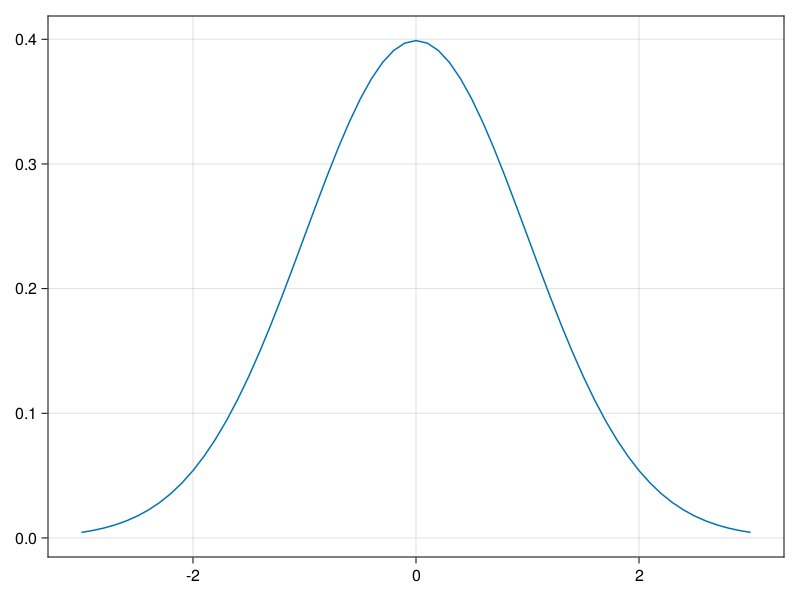

In [107]:
using CairoMakie
CairoMakie.activate!()

let
    x = -3:0.1:3
    y = pdf.(Normal(), x)
    lines(x, y)
end

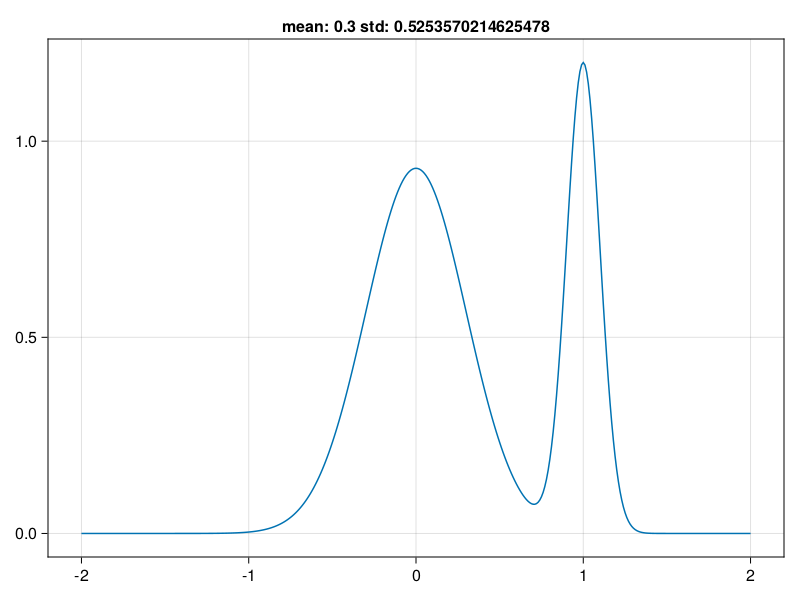

In [108]:
let
    d = MixtureModel(Normal[
            Normal(0, 0.3), Normal(1, 0.1)], 
        [0.7, 0.3])
    x = -2:0.01:2
    y = pdf.(d, x)
    m = mean(d)
    s = std(d)
    lines(x, y, axis=(; title="mean: $(m) std: $(s)"))
end

In [109]:
x = [1, 3, 4, 1, 3, 1]
g = unique(x);
show(g);
## [1, 3, 4]
[count(xi -> xi == gk, x) for gk in g] |> show

[1, 3, 4]

[3, 2, 1]

In [110]:
rle([3,3,1,1,1,2,2])


([3, 1, 2], [2, 3, 2])

In [111]:
inverse_rle([3, 1, 2], [2, 3, 2]) |> show

[3, 3, 1, 1, 1, 2, 2]

In [112]:
x = [1, 3, 4, 1, 3, 1]
@show sort(unique(x));

sort(unique(x)) = [1, 3, 4]


In [113]:
@show StatsBase.counts(x);

StatsBase.counts(x) = [3, 0, 2, 1]


在包和函数之间使用`.` 连接

In [115]:
@show counts(x);

counts(x) = [3, 0, 2, 1]


In [116]:
StatsBase.fit(Histogram, [1, 2, 3, 2, 2, 3],
    [0.5, 1.5, 2.5, 3.5])

Histogram{Int64, 1, Tuple{Vector{Float64}}}
edges:
  [0.5, 1.5, 2.5, 3.5]
weights: [1, 3, 2]
closed: left
isdensity: false

In [117]:
quantile(rand(1000))

5-element Vector{Float64}:
 0.00061208621838027
 0.26729657248814825
 0.5100464772980691
 0.7506837397538798
 0.9975850011918744

In [118]:
quantile(rand(1000), [0.01, 0.99])

2-element Vector{Float64}:
 0.011542435681003603
 0.9893833678493836

其中的 `rand()` 是用于生成标准均匀分布的随机数向量。

In [119]:
StatsBase.tiedrank([3,1,2,4,2]) |> show

[4.0, 1.0, 2.5, 5.0, 2.5]

In [121]:
StatsBase.denserank([3,1,2,4,2])|>show

[3, 1, 2, 4, 2]

In [122]:
StatsBase.zscore([3,1,2,4,2])|>show

[0.5262348115842176, -1.2278812270298407, -0.3508232077228116, 1.403292830891247, -0.3508232077228116]

In [1]:
using DataFrames, CSV, DataFramesMeta
using CategoricalArrays
using Statistics

In [3]:
using Random
Random.seed!(33)

TaskLocalRNG()

In [4]:
function cvind(N, k)
    ## 每组的大致点数
    gs = N ÷ k
    ## 将1到N下标随机乱序
    index = shuffle(collect(1:N))
    ## 指定组规模分组，这可能会使得最后一个组仅有几个点
    folds = collect(Iterators.partition(index, gs))
    ## 如果gs*k不等于N，将最后一个点很少的组与倒数第二个组合并
    if length(folds) > k
        folds[k] = vcat(folds[k], folds[k+1])
        deleteat!(folds, k+1)
    end
    return folds
end # function cvind

cvind (generic function with 1 method)

In [5]:
function kfolds(dat, ind)
    ## 折数
    k = length(ind)
    ## 所有数据的下标
    ind1 = collect(1:size(dat, 1))
    ## 用字典形式返回结果，每一项是编号到字典的映射，
    ## 每一折有留出的用来评估的折以及其余折合并的数据集
    res = Dict{Int, Dict}()
    
    for i = 1:k
        ## 对第i折的产生训练集和测试集
        res2 = Dict{String, DataFrame}()
        ## 去掉第i折作为测试集，其余k-1折皆为训练集
        tr = setdiff(ind1, ind[i])
        res2["training"] = dat[tr, :]
        res2["testing"] = dat[ind[i], :]
        res[i] = res2
    end
    return res
end

kfolds (generic function with 1 method)

In [8]:
using StatsBase, Distances

In [9]:
function maj_vote(yn)
    # StatsBase.countmap是输入整数值，返回频数表的函数
    cm = countmap(yn)
    mv = -999
    lab = nothing
    tot = 1e-8
    for (k, v) in cm
        tot += v
        if v > mv
            mv = v
            lab = k
        end
    end
    prop = mv / tot
    return [lab, prop]
end

maj_vote (generic function with 1 method)

In [15]:
countmap([1 3 2 5 5])

Dict{Int64, Int64} with 4 entries:
  5 => 2
  2 => 1
  3 => 1
  1 => 1

In [17]:
n,p=size([1 2 3])

(1, 3)

In [18]:
n

1

In [19]:
p

3

In [21]:
function knn(x, y, x_new, k)
    n, p = size(x)
    n2, p2 = size(x_new)
    ynew = zeros(n2, 2)
    
    for i in 1:n2
        # 对每个新样品
        res = zeros(n, 2)
        for j in 1:n
            # 与每个训练样品计算曼哈顿距离, 库Distances.cityblock
            res[j, :] = [j, cityblock(x[j, :], x_new[i, :])]
        end
        # 按距离和序号排序
        # sortslices对多维数组的某一维排序
        res2 = sortslices(res, dims = 1, by = x -> (x[2], x[1]))
        # 取最小的k个距离对应的训练样本序号
        ind = convert(Array{Int}, res2[1:k, 1])
        # 按这k个训练样本的因变量值（标签）进行多数投票
        ynew[i,:] = maj_vote(y[ind])
    end # for i
    return ynew
end

# 计算错判率
function knnmcr(yp, ya)
    disagree = Array{Int8}(ya .!= yp)
    mcr = mean(disagree)
    return mcr
end

knnmcr (generic function with 1 method)

In [24]:
using Distributions, StatsBase, DataFrames, Distances

## 生成模拟数据
df_3 = DataFrame(
    y=[0, 1],
    size=[250, 250],
    x1=[2.0, 0.0],
    x2=[-1.0, -2.0])

,y,size,x1,x2
,Int64,Int64,Float64,Float64
1,0,250,2.0,-1.0
2,1,250,0.0,-2.0


In [26]:
df_knn = by(df_3, :y) do df
    DataFrame(
        x_1=rand(Normal(df[1, :x1], 1), df[1, :size]),
        x_2=rand(Normal(df[1, :x2], 1), df[1, :size]))
end

## 设置交叉验证的参数
N = size(df_knn)[1]
kcv = 5

## 生成交叉验证用的下标分组
a_ind = cvind(N, kcv)

## 生成交叉验证用的5折的轮流的训练集和测试集
d_cv = kfolds(df_knn, a_ind)

## 设置knn的参数
k = 15 # 最大近邻个数
knnres = zeros(k, 3)

MethodError: MethodError: no method matching combine(::var"#17#18", ::DataFrame, ::Symbol)
Closest candidates are:
  combine(!Matched::AbstractDataFrame, ::Any...; renamecols) at ~/.julia/packages/DataFrames/JZ7x5/src/abstractdataframe/selection.jl:1516
  combine(::Union{Function, Type}, ::AbstractDataFrame; renamecols) at ~/.julia/packages/DataFrames/JZ7x5/src/abstractdataframe/selection.jl:1520
  combine(!Matched::Pair, ::AbstractDataFrame; renamecols) at ~/.julia/packages/DataFrames/JZ7x5/src/abstractdataframe/selection.jl:1527
  ...

In [ ]:
## 尝试不同的尽量个数i，用CV比较错判率
for i = 1:k
    cv_res = zeros(kcv)
    for j = 1:kcv # 对每一折
        tr_a = combine(Matrix, d_cv[j]["training"][[:x_1, :x_2]])
        ytr_a = convert(Vector, d_cv[j]["training"][:y])
        tst_a = convert(Matrix, d_cv[j]["testing"][[:x_1, :x_2]])
        ytst_a = convert(Vector, d_cv[j]["testing"][:y])
        pred = knn(tr_a, ytr_a, tst_a, i)[:, 1]
        cv_res[j] = knnmcr(pred, ytst_a)
    end
    # 结果第一列：近邻数
    knnres[i, 1] = i
    # 结果第二列：CV错判率
    knnres[i, 2] = mean(cv_res)
    # 结果第三列：错判率的标准误差
    knnres[i, 3] = std(cv_res) / sqrt(kcv)
end
knnres

In [20]:
using DecisionTree, Random
Random.seed!(35)

## food training data from chapter 3
y = df_food[:gpa]
tmp = convert(Array, df_food[setdiff(names(df_food), [:gpa])] )
xmat = convert(Array{Float64}, collect(Missings.replace(tmp, 0)))
names_food = setdiff(names(df_food), [:gpa])

# defaults to regression tree if y is a Float array
model = build_tree(y, xmat)


UndefVarError: UndefVarError: df_food not defined

In [34]:
using StatsBase, Random, Statistics
Random.seed!(46)

A1 = [10, 27, 31, 40, 46, 50, 52, 104, 146]
median(A1)
# 46.0

n = length(A1)
m = 100000
theta = zeros(m)

for i = 1:m
    theta[i] = median(sample(A1, n, replace=true))
end

In [35]:
theta

100000-element Vector{Float64}:
 50.0
 52.0
 50.0
 50.0
 50.0
 40.0
 52.0
 46.0
 46.0
 46.0
  ⋮
 50.0
 46.0
 46.0
 46.0
 46.0
 31.0
 31.0
 50.0
 50.0

In [36]:
mean(theta)

45.80283

In [37]:
std(theta)

12.969460129861252

In [38]:
function boost_se(theta_h)
    m = length(theta_h)
    c1 = 1.0/(m-1)
    c2 = mean(theta_h)
    res = map(x -> (x-c2)^2,theta_h)
    return(sqrt(c1*sum(res)))
end

boost_se (generic function with 1 method)

In [39]:
boost_se(theta)

12.969460129861252

In [40]:
mean(theta)-median(theta)

-0.19716999999999985

In [41]:
quantile(theta,[0.025,0.975])

2-element Vector{Float64}:
  27.0
 104.0

## 随机森林

In [47]:
param_cv_reg = [
    "silent" => 1,
    "verbose" => 0,
    "booster" => "gbtree",
    "objective" => "reg:linear",
    "save_period" => 0,
    "subsample" => 0.75,
    "colsample_bytree" => 0.75,
    "lambda" => 1,
    "gamma" => 0
]

9-element Vector{Pair{String, Any}}:
           "silent" => 1
          "verbose" => 0
          "booster" => "gbtree"
        "objective" => "reg:linear"
      "save_period" => 0
        "subsample" => 0.75
 "colsample_bytree" => 0.75
           "lambda" => 1
            "gamma" => 0

## PCA

In [42]:
using LinearAlgebra

## 通过奇异值分解计算主成分分析
## 输入: $n \times p$数据集矩阵
function pca_svd(X)
    n, p = size(X)
    k = min(n, p)
    S = svd(X)
    ## 奇异值向量
    D = S.S[1:k]
    ## 右特征向量
    V = transpose(S.Vt)[:, 1:k]
    ## 主成分的标准差
    sD = D ./ sqrt(n - 1)
    rotation = V
    ## 主成分得分矩阵
    projection = X * V
    return (Dict(
        "sd" => sD, # 主成分的标准差
        "rotation" => rotation, # 右乘观测数据阵用的矩阵
        "projection" => projection # 主成分得分矩阵
    ))
end

pca_svd (generic function with 1 method)

In [43]:
using RDatasets, DataFrames, Statistics
df_crabs = RDatasets.dataset("MASS", "crabs")
first(df_crabs, 3)

,Sp,Sex,Index,FL,RW,CL,CW,BD
,Cat…,Cat…,Int32,Float64,Float64,Float64,Float64,Float64
1,B,M,1,8.1,6.7,16.1,19.0,7.0
2,B,M,2,8.8,7.7,18.1,20.8,7.4
3,B,M,3,9.2,7.8,19.0,22.4,7.7


In [126]:
crab_mat = convert(Array{Float64}, df_crabs[:, [:FL, :RW, :CL, :CW, :BD]])
mean_crab = mean(crab_mat, dims=1)
crab_mat_c = crab_mat .- mean_crab;

MethodError: MethodError: Cannot `convert` an object of type 
  DataFrame to an object of type 
  Array{Float64}
Closest candidates are:
  convert(::Type{Array{T}}, !Matched::StaticArraysCore.SizedArray{S, T, N, M, Array{T, M}}) where {S, T, N, M} at ~/.julia/packages/StaticArrays/VLqRb/src/SizedArray.jl:79
  convert(::Type{Array{T}}, !Matched::StaticArraysCore.SizedArray{S, T, N, M, TData} where {N, M, TData<:AbstractArray{T, M}}) where {T, S} at ~/.julia/packages/StaticArrays/VLqRb/src/SizedArray.jl:76
  convert(::Type{T}, !Matched::Factorization) where T<:AbstractArray at /Applications/Julia-1.8.app/Contents/Resources/julia/share/julia/stdlib/v1.8/LinearAlgebra/src/factorization.jl:58
  ...

In [125]:
pca1 = pca_svd(crab_mat_c)

pca_df2 = DataFrame(
  pc1 = pca1["projection"][:,1],
  pc2 = pca1["projection"][:,2],
  pc3 = pca1["projection"][:,3],
  pc4 = pca1["projection"][:,4],
  pc5 = pca1["projection"][:,5],
  label = map(string, repeat(1:4, inner = 50))
);
cumsum(pca1["sd"][1:2] .^ 2) ./ sum(pca1["sd"] .^ 2)

UndefVarError: UndefVarError: crab_mat_c not defined

In [45]:
using Gadfly
Gadfly.plot(pca_df2, x=:pc1, y=:pc2, color=:label)

UndefVarError: UndefVarError: pca_df2 not defined

In [124]:
using CSV, DataFrames, Statistics, Clustering, Gadfly, Random
Random.seed!(429)

x2_df = DataFrame!(CSV.File("x2.csv"))
Gadfly.plot(
    x2_df, x=:V1, y=:V2,
    Geom.point)

ArgumentError: ArgumentError: "x2.csv" is not a valid file or doesn't exist

In [127]:
A1 = [1 -2 2; 1 -1 2; -1 1 1]

3×3 Matrix{Int64}:
  1  -2  2
  1  -1  2
 -1   1  1

In [128]:
using LinearAlgebra
res1 = LinearAlgebra.lu(A1)
res1.L

3×3 Matrix{Float64}:
  1.0   0.0  0.0
  1.0   1.0  0.0
 -1.0  -1.0  1.0

其中Julia在一个对象的子元素的调用方法是`.`而对于R来说一般的方法是`$`

In [129]:
res1.U


3×3 Matrix{Float64}:
 1.0  -2.0  2.0
 0.0   1.0  0.0
 0.0   0.0  3.0

In [130]:
res1.P

3×3 Matrix{Float64}:
 1.0  0.0  0.0
 0.0  1.0  0.0
 0.0  0.0  1.0

In [131]:
using Random, Distributions
using StatsBase, DataFrames
Random.seed!(101)
y = rand(Poisson(2), 100);

In [132]:
tab11 = DataFrame(
    y=minimum(y):maximum(y),
    count=StatsBase.counts(y))

,y,count
,Int64,Int64
1,0,10
2,1,30
3,2,28
4,3,25
5,4,5
6,5,2


In [133]:
using CairoMakie
CairoMakie.activate!()
using AlgebraOfGraphics

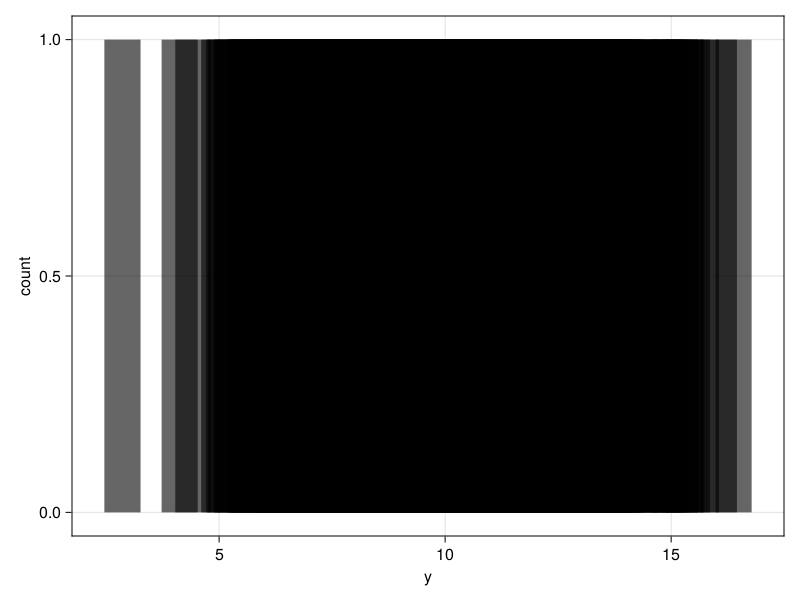

In [139]:
plt = data((;y=y))*mapping(:y)*frequency()
AlgebraOfGraphics.draw(plt)

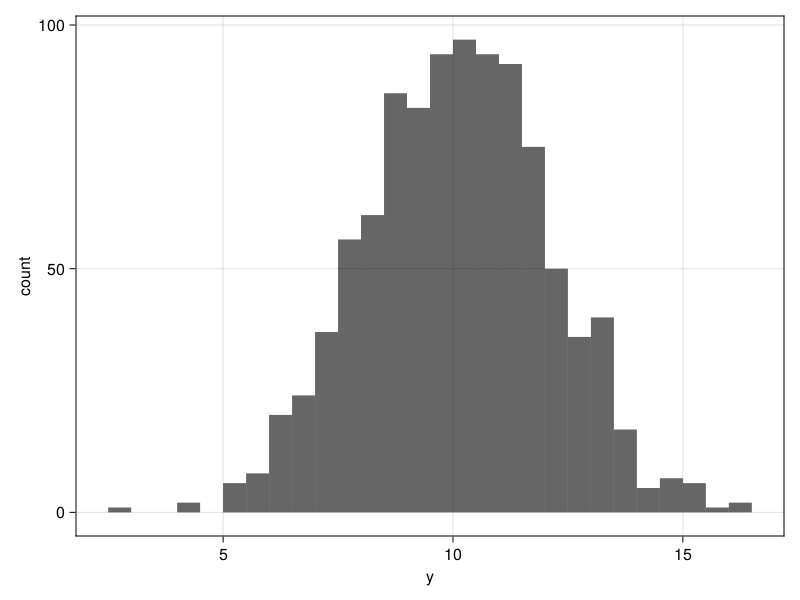

In [138]:

Random.seed!(101)
y = rand(Normal(10, 2), 1000);
plt = data((; y=y)) * mapping(:y) * histogram(bins=30)
AlgebraOfGraphics.draw(plt)